In [10]:
import os
os.getcwd()


'/Users/yashikamalmith/Desktop/ml-heart-disease-assignment'

In [11]:
import numpy as np

In [12]:
import pandas as pd

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [14]:
# Load heart disease dataset
data = pd.read_csv("heart.csv")

In [15]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [16]:
# Display all column names
print("Columns in dataset:")
print(data.columns)

Columns in dataset:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [17]:
data.shape

(1025, 14)

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [19]:
# Display summary statistics
print("Statistical Summary:")
print(data.describe())

Statistical Summary:
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.529756   149.114146     0.336585     1.071512   
std       0.356527     0.527878    23.005724     0.472772     1.175053   
min       0.000000     0.

In [20]:
# Check missing values in each column
print("Missing Values:")
print(data.isnull().sum())

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [21]:
# Count duplicate rows
print("Number of duplicate rows:", data.duplicated().sum())

Number of duplicate rows: 723


In [22]:
# Remove duplicate rows
data = data.drop_duplicates()

# Check new shape after removing duplicates
print("Shape after removing duplicates:", data.shape)

Shape after removing duplicates: (302, 14)


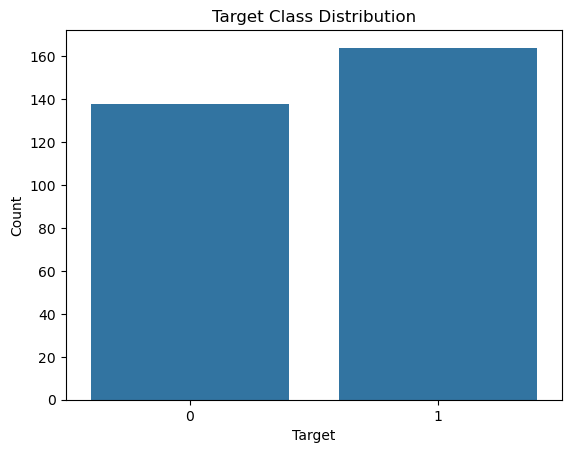

In [23]:
# Visualize target class distribution
sns.countplot(x="target", data=data)
plt.title("Target Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

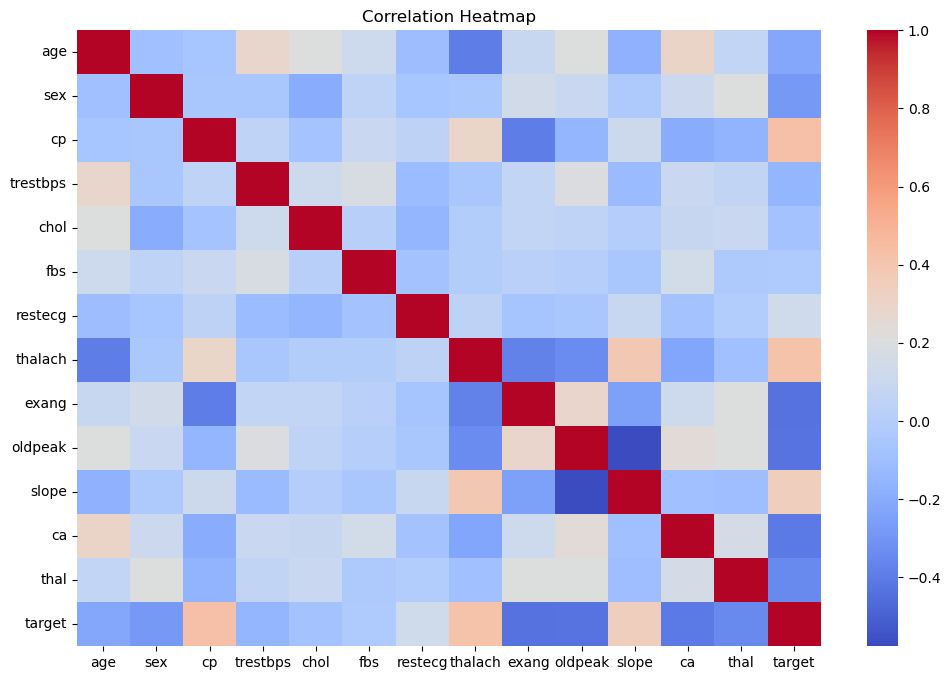

In [24]:
# Calculate correlation matrix
corr = data.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [25]:
# Separate input features and output target
X = data.drop("target", axis=1)
y = data["target"]

# Display shape of X and y
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (302, 13)
Target vector shape: (302,)


In [26]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display shapes of split data
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (241, 13)
X_test shape: (61, 13)
y_train shape: (241,)
y_test shape: (61,)


In [27]:
# Create StandardScaler object
scaler = StandardScaler()

# Fit scaler on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [28]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

In [29]:
X_train_scaled_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,1.421944,-1.445595,0.986493,-0.973041,5.882908,-0.398314,-1.008059,0.408240,-0.652714,0.527263,-0.697127,-0.722716,1.075838
1,-0.465841,0.691757,-0.954281,0.756507,-0.885696,-0.398314,-1.008059,-1.104705,1.532065,-0.083233,-0.697127,-0.722716,1.075838
2,0.422528,0.691757,-0.954281,-0.197726,-0.588175,-0.398314,-1.008059,-0.882213,1.532065,1.050546,-0.697127,2.132606,1.075838
3,1.644036,0.691757,0.986493,0.517949,0.118437,-0.398314,-1.008059,-0.214737,-0.652714,0.876119,-0.697127,2.132606,1.075838
4,-1.021072,-1.445595,0.016106,-1.151959,-1.629499,-0.398314,0.875214,-0.570724,-0.652714,-0.868157,-0.697127,-0.722716,-0.544643


In [30]:
# Initialize and train SVM with RBF kernel
# RBF (Radial Basis Function) kernel works well for non-linear data
svm_model = SVC(
    kernel='rbf',       # RBF kernel for non-linear classification
    C=1.0,              # regularization parameter
    gamma='scale',      # kernel coefficient
    probability=True,   # enable probability estimates (needed for ROC curve)
    random_state=42
)

svm_model.fit(X_train, y_train)
print('SVM model trained successfully!')

SVM model trained successfully!


In [31]:
# Save cleaned dataset
data.to_csv("dataset/processed/heart_cleaned.csv", index=False)

print("Processed dataset saved.")

Processed dataset saved.


In [32]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report


In [33]:
svm_model = SVC(kernel='rbf', probability=True, random_state=42)

In [34]:
svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [35]:
svm_pred = svm_model.predict(X_test_scaled)

In [36]:
print("===== SVM Evaluation =====")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall:", recall_score(y_test, svm_pred))
print("F1 Score:", f1_score(y_test, svm_pred))

===== SVM Evaluation =====
Accuracy: 0.7704918032786885
Precision: 0.7714285714285715
Recall: 0.8181818181818182
F1 Score: 0.7941176470588235


In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
svm_cm = confusion_matrix(y_test, svm_pred)

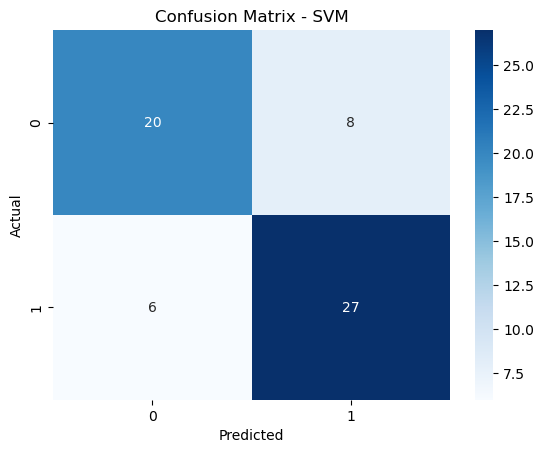

In [39]:
sns.heatmap(svm_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [40]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.77      0.71      0.74        28
           1       0.77      0.82      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



In [41]:
from sklearn.metrics import roc_auc_score, roc_curve


In [42]:
svm_prob = svm_model.predict_proba(X_test_scaled)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, svm_prob))

ROC-AUC Score: 0.841991341991342


In [43]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(SVC(probability=True), param_grid, cv=5)
grid_svm.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_svm.best_params_)

Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
